# Odor Label Consistency Analysis — GoodScents vs Leffingwell

**Datasets:** goodscents, leffingwell (the same 2 sources merged into `hmcn_dataset.csv`)

**Goal:** quantify how *inconsistent* odor descriptor labeling is between these two
specific sources, for the 138 target odor descriptors, restricted to molecules (SMILES)
that appear in both.

With only 2 datasets, every metric below reduces to a **single pairwise value** per
molecule / per label — there's no averaging over multiple dataset pairs anymore, since
there's only one pair: (goodscents, leffingwell).

| # | Metric | Level | What it tells you |
|---|--------|-------|--------------------|
| 1 | Molecule Consistency Score | per molecule | label-set agreement for one molecule between the 2 sources |
| 2 | Positive Specific Agreement (PA) | per label | agreement on a label, ignoring trivial double-negative agreement |
| 3 | Label Density | per dataset | average number of positive labels per molecule (annotation granularity) |
| 4 | Prevalence Correlation | single number | do the 2 datasets agree on which smells are common/rare overall? |
| 5 | Cohen's kappa | per label | chance-corrected pairwise agreement, cross-checked against PA |

Set `DATA_DIR` below to the folder containing the `*_processed.csv` files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import spearmanr
from collections import Counter
%matplotlib inline

pd.set_option('display.width', 120)

DATA_DIR = '/mnt/user-data/uploads'  # <-- change this if running elsewhere

FILES = {
    'goodscents':  f'{DATA_DIR}/goodscents_processed.csv',
    'leffingwell': f'{DATA_DIR}/leffingwell_processed.csv',
}
DATASET_NAMES = list(FILES.keys())
print(f"{len(DATASET_NAMES)} datasets registered.")

2 datasets registered.


## Step 1 — Build the 138-label vocabulary and load all 8 datasets

All 8 files share an identical 583-column label schema. Of the 138 target odor
descriptors, 135 match a column exactly. The remaining 3 are resolved as:

- `black currant` → column `currant black currant`
- `mint` → folded into `minty`
- `fruit skin` → **constructed** as the OR of `apple skin`, `cucumber skin`, `grape skin`,
  `pear skin`, `plum skin` (a molecule is positive for `fruit skin` if any of these fire)

This gives a clean set of 138 usable binary labels per molecule, per dataset.

In [2]:
TARGET_138 = ['alcoholic', 'aldehydic', 'alliaceous', 'almond', 'amber', 'animal', 'anisic', 'apple',
'apricot', 'aromatic', 'balsamic', 'banana', 'beefy', 'bergamot', 'berry', 'bitter', 'black currant',
'brandy', 'burnt', 'buttery', 'cabbage', 'camphoreous', 'caramellic', 'cedar', 'celery', 'chamomile',
'cheesy', 'cherry', 'chocolate', 'cinnamon', 'citrus', 'clean', 'clove', 'cocoa', 'coconut', 'coffee',
'cognac', 'cooked', 'cooling', 'cortex', 'coumarinic', 'creamy', 'cucumber', 'dairy', 'dry', 'earthy',
'ethereal', 'fatty', 'fermented', 'fishy', 'floral', 'fresh', 'fruit skin', 'fruity', 'garlic', 'gassy',
'geranium', 'grape', 'grapefruit', 'grassy', 'green', 'hawthorn', 'hay', 'hazelnut', 'herbal', 'honey',
'hyacinth', 'jasmin', 'juicy', 'ketonic', 'lactonic', 'lavender', 'leafy', 'leathery', 'lemon', 'lily',
'malty', 'meaty', 'medicinal', 'melon', 'metallic', 'milky', 'mint', 'muguet', 'mushroom', 'musk',
'musty', 'natural', 'nutty', 'odorless', 'oily', 'onion', 'orange', 'orangeflower', 'orris', 'ozone',
'peach', 'pear', 'phenolic', 'pine', 'pineapple', 'plum', 'popcorn', 'potato', 'powdery', 'pungent',
'radish', 'raspberry', 'ripe', 'roasted', 'rose', 'rummy', 'sandalwood', 'savory', 'sharp', 'smoky',
'soapy', 'solvent', 'sour', 'spicy', 'strawberry', 'sulfurous', 'sweaty', 'sweet', 'tea', 'terpenic',
'tobacco', 'tomato', 'tropical', 'vanilla', 'vegetable', 'vetiver', 'violet', 'warm', 'waxy', 'weedy',
'winey', 'woody']
print(f"Target labels: {len(TARGET_138)}")

RENAME_MAP = {'black currant': 'currant black currant', 'mint': 'minty'}
FRUIT_SKIN_SOURCES = ['apple skin', 'cucumber skin', 'grape skin', 'pear skin', 'plum skin']
SIMPLE_LABELS = [l for l in TARGET_138 if l not in ('fruit skin',)]

def load_dataset(name, path):
    needed_cols = ['SMILES'] + [RENAME_MAP.get(l, l) for l in SIMPLE_LABELS if l != 'fruit skin'] + FRUIT_SKIN_SOURCES
    needed_cols = list(dict.fromkeys(needed_cols))  # dedupe, preserve order
    df = pd.read_csv(path, usecols=needed_cols)
    df = df.rename(columns={v: k for k, v in RENAME_MAP.items()})
    df['fruit skin'] = (df[FRUIT_SKIN_SOURCES].sum(axis=1) > 0).astype(int)
    df = df.drop(columns=FRUIT_SKIN_SOURCES)
    df = df.drop_duplicates(subset='SMILES', keep='first').set_index('SMILES')
    return df[TARGET_138]

DFS = {}
for name, path in FILES.items():
    DFS[name] = load_dataset(name, path)
    print(f"{name}: {DFS[name].shape[0]} molecules")

assert all(DFS[n].shape[1] == 138 for n in DATASET_NAMES), "label count mismatch!"
print("\nAll datasets loaded with 138 usable labels each.")

Target labels: 138
goodscents: 4342 molecules


leffingwell: 3523 molecules



All datasets loaded with 138 usable labels each.


/tmp/ipykernel_589/2472283523.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fruit skin'] = (df[FRUIT_SKIN_SOURCES].sum(axis=1) > 0).astype(int)
/tmp/ipykernel_589/2472283523.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fruit skin'] = (df[FRUIT_SKIN_SOURCES].sum(axis=1) > 0).astype(int)


## Step 2 — Identify shared molecules

A molecule `m` is only usable for cross-dataset consistency metrics if it appears in
**k ≥ 2** of the 8 datasets. We build, for every such molecule, the set of datasets
that contain it.

In [3]:
smiles_sets = {name: set(DFS[name].index) for name in DATASET_NAMES}
smiles_membership = Counter()
for name, s in smiles_sets.items():
    for smi in s:
        smiles_membership[smi] += 1

shared_smiles = [smi for smi, k in smiles_membership.items() if k >= 2]
print(f"Molecules in >=2 datasets: {len(shared_smiles)}")

# which datasets contain each shared molecule
smiles_to_datasets = {smi: [n for n in DATASET_NAMES if smi in smiles_sets[n]] for smi in shared_smiles}

Molecules in >=2 datasets: 726


## Metric 1 — Molecule-level Consistency Score

For molecule $m$ present in datasets $i \in D_m$ ($|D_m| = k \ge 2$), let $S_i$ be its
set of positive labels (out of the 138) in dataset $i$.

For every pair $(i,j)$ with $i,j \in D_m$, $i<j$:

$$J_{i,j} = \frac{|S_i \cap S_j|}{|S_i \cup S_j|}$$

If $S_i = S_j = \emptyset$ (both datasets label nothing for $m$), $J_{i,j}$ is **excluded**
from the average — treated as uninformative rather than agreement (since `odorless` is
already an explicit label in the 138, a truly odorless molecule should show up as
`odorless=1`, not as an empty label set).

$$\text{Score}_m = \frac{1}{|P_m|}\sum_{(i,j) \in P_m} J_{i,j}$$

where $P_m$ is the set of valid (non-0/0) pairs among the $\binom{k}{2}$ dataset pairs
containing $m$.

In [4]:
def label_set(name, smi):
    row = DFS[name].loc[smi]
    return set(row.index[row.values == 1])

scores = []
for smi in shared_smiles:
    ds = smiles_to_datasets[smi]
    pair_jaccards = []
    for i, j in combinations(ds, 2):
        Si, Sj = label_set(i, smi), label_set(j, smi)
        if not Si and not Sj:
            continue  # exclude 0/0 pairs
        union = Si | Sj
        pair_jaccards.append(len(Si & Sj) / len(union))
    if pair_jaccards:
        scores.append({'SMILES': smi, 'k': len(ds), 'n_valid_pairs': len(pair_jaccards),
                        'Score_m': np.mean(pair_jaccards)})

score_df = pd.DataFrame(scores)
print(f"Molecules with a defined Score_m: {len(score_df)} / {len(shared_smiles)}")
score_df.describe()

Molecules with a defined Score_m: 724 / 726


,k,n_valid_pairs,Score_m
count,724.0,724.0,724.000000
mean,2.0,1.0,0.313708
std,0.0,0.0,0.237515
min,2.0,1.0,0.000000
25%,2.0,1.0,0.166667
50%,2.0,1.0,0.272727
75%,2.0,1.0,0.444444
max,2.0,1.0,1.000000


### Plot 1 — Distribution of Score_m

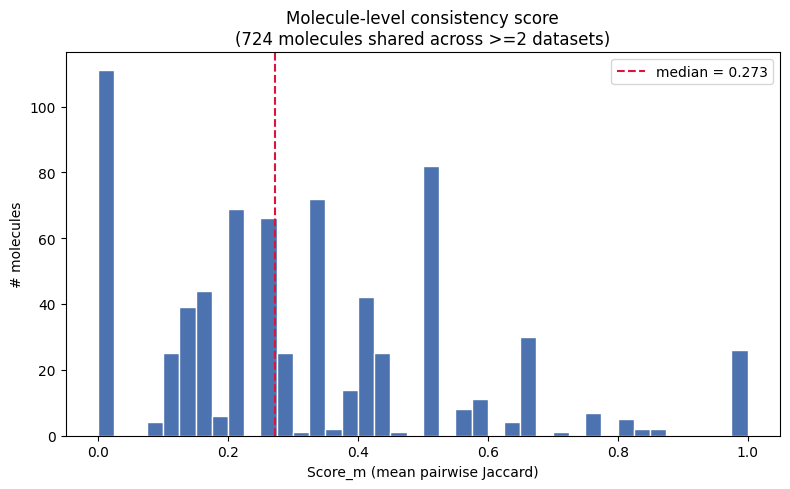

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(score_df['Score_m'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(score_df['Score_m'].median(), color='crimson', linestyle='--',
           label=f"median = {score_df['Score_m'].median():.3f}")
ax.set_xlabel('Score_m (mean pairwise Jaccard)')
ax.set_ylabel('# molecules')
ax.set_title(f'Molecule-level consistency score\n({len(score_df)} molecules shared across >=2 datasets)')
ax.legend()
plt.tight_layout()
plt.show()

*(Plot 2 — Score_m vs k — is omitted here: with only 2 datasets, every shared molecule
has k=2 by construction, so there's no variation in k to plot against.)*

## Metric 2 — Positive Specific Agreement (PA) per label

For label $L$ and dataset pair $(i,j)$, restricted to molecules present in **both**:

- $a$ = # molecules where both datasets say $L=1$
- $b$ = # molecules where only $i$ says $L=1$
- $c$ = # molecules where only $j$ says $L=1$

$$PA_{i,j}(L) = \frac{2a}{2a + b + c}$$

(the Dice coefficient on positives — this deliberately ignores the $d$ = both-negative
cell, which is where the class-imbalance inflation problem lives). Pairs with
$2a+b+c=0$ (neither dataset ever calls $L$ on their shared molecules) are excluded.

$$PA(L) = \frac{1}{|\text{valid pairs}|}\sum_{(i,j)} PA_{i,j}(L)$$

In [6]:
pairs = list(combinations(DATASET_NAMES, 2))

def abc_for_pair(name_i, name_j, label):
    common = smiles_sets[name_i] & smiles_sets[name_j]
    if not common:
        return 0, 0, 0
    common = list(common)
    vi = DFS[name_i].loc[common, label].values
    vj = DFS[name_j].loc[common, label].values
    a = int(((vi==1) & (vj==1)).sum())
    b = int(((vi==1) & (vj==0)).sum())
    c = int(((vi==0) & (vj==1)).sum())
    return a, b, c

pa_results = []
for label in TARGET_138:
    pa_vals = []
    for ni, nj in pairs:
        a, b, c = abc_for_pair(ni, nj, label)
        denom = 2*a + b + c
        if denom > 0:
            pa_vals.append(2*a/denom)
    pa_results.append({'label': label, 'PA': np.mean(pa_vals) if pa_vals else np.nan,
                        'n_valid_pairs': len(pa_vals)})

pa_df = pd.DataFrame(pa_results).sort_values('PA')
pa_df.to_csv('/mnt/user-data/outputs/pa_per_label_gs_lw.csv', index=False)
pa_df

,label,PA,n_valid_pairs
3,almond,0.0,1
4,amber,0.0,1
6,anisic,0.0,1
9,aromatic,0.0,1
16,black currant,0.0,1
...,...,...,...
32,clove,NaN,0
61,hawthorn,NaN,0
112,sandalwood,NaN,0
115,smoky,NaN,0


### Plot 3 — PA_L sorted (bottom 20 / top 20)

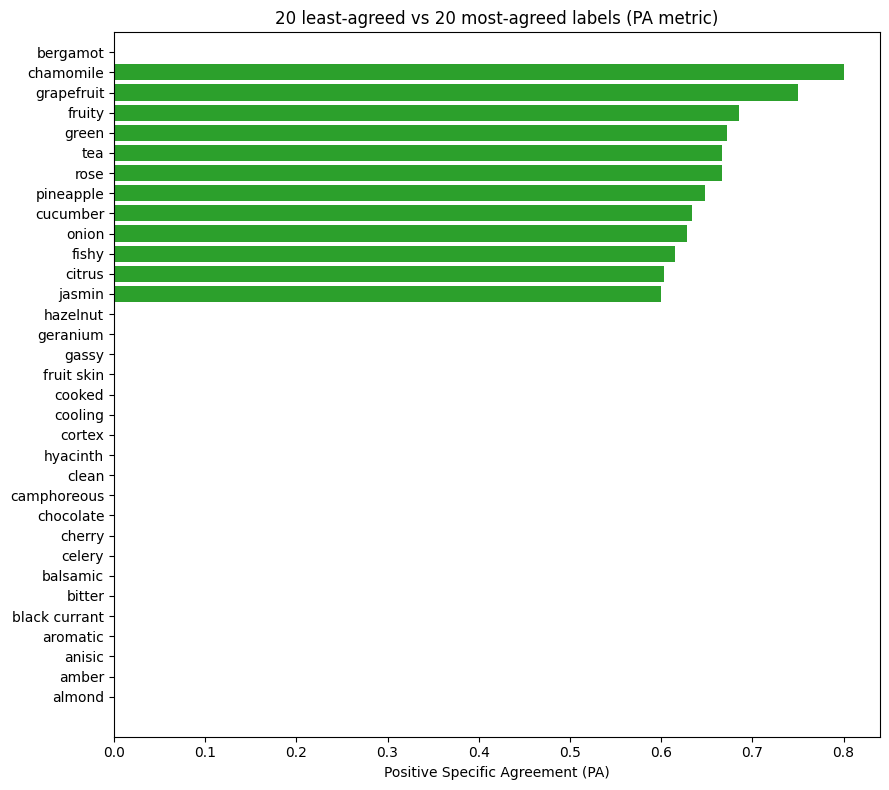

In [7]:
combo = pd.concat([pa_df.head(20), pa_df.tail(20)])
fig, ax = plt.subplots(figsize=(9,8))
colors = ['#d62728' if v < 0.3 else '#2ca02c' for v in combo['PA']]
ax.barh(combo['label'], combo['PA'], color=colors)
ax.set_xlabel('Positive Specific Agreement (PA)')
ax.set_title('20 least-agreed vs 20 most-agreed labels (PA metric)')
plt.tight_layout()
plt.show()

## Reference metric — Krippendorff's alpha (from previous session)

For comparison against $PA(L)$, we recompute Krippendorff's alpha per label: treat
each dataset as a "rater" giving a nominal 0/1 rating to each shared molecule, with
missing values (dataset doesn't contain the molecule) left as NaN. Alpha corrects for
chance agreement and handles the variable number of raters per molecule natively.

$$\alpha = 1 - \frac{D_o}{D_e}$$

where $D_o$ is observed disagreement and $D_e$ is expected disagreement under chance.

In [8]:
import krippendorff

def alpha_for_label(label):
    mat = np.full((len(DATASET_NAMES), len(shared_smiles)), np.nan)
    for i, name in enumerate(DATASET_NAMES):
        vals = DFS[name].reindex(shared_smiles)[label].values
        mat[i, :] = vals
    try:
        return krippendorff.alpha(reliability_data=mat, level_of_measurement='nominal')
    except Exception:
        return np.nan

alpha_results = [{'label': l, 'alpha': alpha_for_label(l)} for l in TARGET_138]
alpha_df = pd.DataFrame(alpha_results)
merged_pa_alpha = pa_df.merge(alpha_df, on='label')
merged_pa_alpha.to_csv('/mnt/user-data/outputs/pa_vs_alpha_gs_lw.csv', index=False)
merged_pa_alpha.sort_values('alpha').head(10)

,label,PA,n_valid_pairs,alpha
25,metallic,0.0,1,-0.016106
40,soapy,0.0,1,-0.015395
35,solvent,0.0,1,-0.013268
11,clean,0.0,1,-0.010446
15,cooked,0.0,1,-0.008339
38,sweaty,0.0,1,-0.006241
36,natural,0.0,1,-0.006241
8,cherry,0.0,1,-0.004848
16,fruit skin,0.0,1,-0.004848
21,phenolic,0.0,1,-0.004848


### Plot 4 — PA vs Krippendorff's alpha, per label

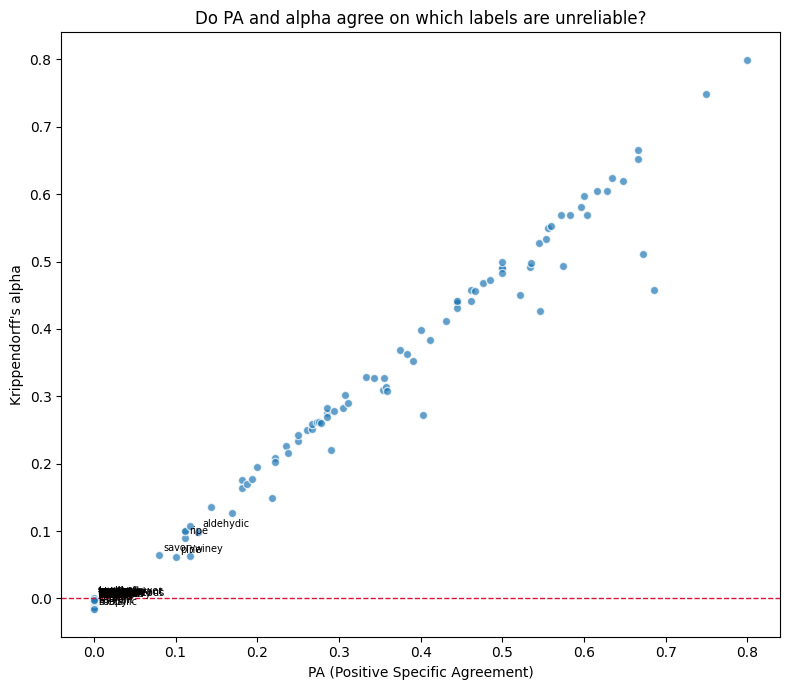

Spearman correlation between PA and alpha across labels: SignificanceResult(statistic=nan, pvalue=nan)


In [9]:
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(merged_pa_alpha['PA'], merged_pa_alpha['alpha'], s=35, alpha=0.7, edgecolor='white')
ax.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax.set_xlabel('PA (Positive Specific Agreement)')
ax.set_ylabel("Krippendorff's alpha")
ax.set_title('Do PA and alpha agree on which labels are unreliable?')
for _, row in merged_pa_alpha[(merged_pa_alpha['alpha']<0.1) | (merged_pa_alpha['PA']<0.1)].iterrows():
    ax.annotate(row['label'], (row['PA'], row['alpha']), fontsize=7, xytext=(3,3), textcoords='offset points')
plt.tight_layout()
plt.show()

print("Spearman correlation between PA and alpha across labels:",
      spearmanr(merged_pa_alpha['PA'], merged_pa_alpha['alpha']))

## Metric 3 — Per-dataset Label Density

For dataset $i$ with molecule set $M_i$:

$$\text{Density}_i = \frac{1}{|M_i|}\sum_{m \in M_i} |S_i(m)|$$

the average number of positive labels (out of 138) per molecule. This is diagnostic,
not a "consistency" metric per se — it tells us whether a low agreement score reflects
genuine perceptual disagreement or simply a difference in **annotation granularity**
(e.g. one source labels molecules richly, another sparsely).

In [10]:
density = pd.Series({name: DFS[name].sum(axis=1).mean() for name in DATASET_NAMES}, name='Density').sort_values()
density

goodscents     3.241133
leffingwell    3.606869
Name: Density, dtype: float64

### Plot 5 — Label density per dataset

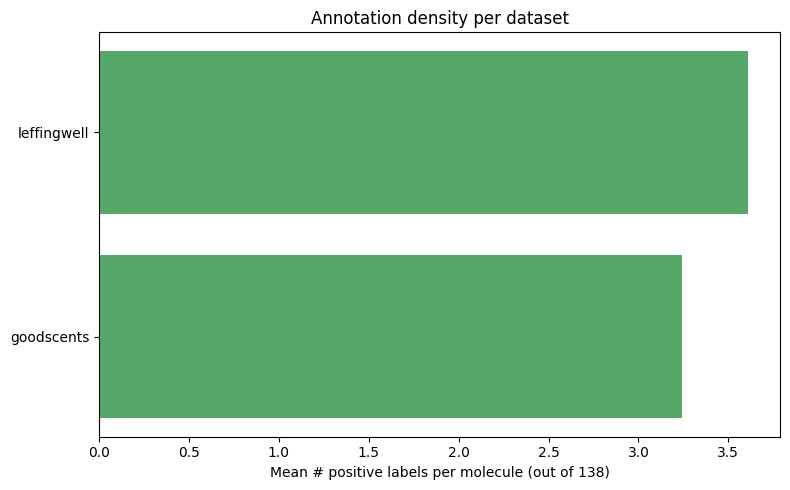

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(density.index, density.values, color='#55A868')
ax.set_xlabel('Mean # positive labels per molecule (out of 138)')
ax.set_title('Annotation density per dataset')
plt.tight_layout()
plt.show()

## Metric 4 — Cross-dataset Prevalence Correlation

For dataset $i$, build the 138-length vector of label prevalences:

$$\text{prev}_i(L) = \frac{1}{|M_i|}\sum_{m \in M_i} \mathbb{1}[L \in S_i(m)] \quad \text{for each of the 138 labels } L$$

For each pair of datasets $(i,j)$, compute the Spearman correlation between their two
138-length prevalence vectors:

$$\rho_{i,j} = \text{Spearman}\big(\text{prev}_i(\cdot),\ \text{prev}_j(\cdot)\big)$$

This is a **dataset-pair-level** metric (not per-label): a high $\rho_{i,j}$ means the
two datasets agree on which smells are common vs. rare overall, even if they disagree
molecule-by-molecule. Result: an 8×8 correlation matrix.

In [12]:
prevalence = pd.DataFrame({name: DFS[name].mean(axis=0) for name in DATASET_NAMES})  # 138 x 8
corr_matrix = prevalence.corr(method='spearman')
corr_matrix.round(2)

,goodscents,leffingwell
goodscents,1.00,0.59
leffingwell,0.59,1.00


In [13]:
# With only 2 datasets, the "matrix" has a single off-diagonal value worth reporting.
rho = corr_matrix.loc['goodscents', 'leffingwell']
print(f"Spearman correlation of the 138-label prevalence profiles, "
      f"goodscents vs leffingwell: rho = {rho:.3f}")

Spearman correlation of the 138-label prevalence profiles, goodscents vs leffingwell: rho = 0.593


## Metric 5 — Cohen's kappa per label (cross-check against PA)

For label $L$, dataset pair $(i,j)$, restricted to the $n$ molecules present in both,
build the full 2×2 table: $a$ (both 1), $b$ ($i$ only), $c$ ($j$ only), $d$ (both 0).

$$p_o = \frac{a+d}{n}, \qquad p_e = \frac{(a+b)(a+c) + (c+d)(b+d)}{n^2}$$

$$\kappa_{i,j} = \frac{p_o - p_e}{1 - p_e}$$

$$\kappa(L) = \text{mean over all pairs with } n>0 \text{ and } p_e \neq 1$$

Unlike $PA(L)$, kappa also credits agreement on absence, but corrects for the chance
level implied by both datasets' marginal positive rates — comparing $\kappa$ vs $PA$
per label tells us whether a low $PA$ reflects genuine disagreement or just one
dataset calling the label positive far more often than the other.

In [14]:
def kappa_for_pair(name_i, name_j, label):
    common = list(smiles_sets[name_i] & smiles_sets[name_j])
    if not common:
        return np.nan
    vi = DFS[name_i].loc[common, label].values
    vj = DFS[name_j].loc[common, label].values
    n = len(common)
    a = int(((vi==1)&(vj==1)).sum()); b = int(((vi==1)&(vj==0)).sum())
    c = int(((vi==0)&(vj==1)).sum()); d = int(((vi==0)&(vj==0)).sum())
    po = (a+d)/n
    pe = ((a+b)*(a+c) + (c+d)*(b+d)) / (n**2)
    if pe == 1:
        return np.nan
    return (po-pe)/(1-pe)

kappa_results = []
for label in TARGET_138:
    kvals = [kappa_for_pair(ni, nj, label) for ni, nj in pairs]
    kvals = [k for k in kvals if not np.isnan(k)]
    kappa_results.append({'label': label, 'kappa': np.mean(kvals) if kvals else np.nan})

kappa_df = pd.DataFrame(kappa_results)
merged_all = merged_pa_alpha.merge(kappa_df, on='label')
merged_all.to_csv('/mnt/user-data/outputs/all_label_metrics_gs_lw.csv', index=False)
merged_all.sort_values('kappa').head(10)

,label,PA,n_valid_pairs,alpha,kappa
25,metallic,0.0,1,-0.016106,-0.009268
35,solvent,0.0,1,-0.013268,-0.008894
39,strawberry,0.0,1,-0.004152,-0.004745
0,almond,0.0,1,-0.002072,-0.002762
21,phenolic,0.0,1,-0.004848,-0.002416
43,warm,0.0,1,-0.002764,-0.002209
9,chocolate,0.0,1,-0.002764,-0.002209
6,balsamic,0.0,1,-0.000690,-0.001379
7,celery,0.0,1,-0.002072,0.000000
8,cherry,0.0,1,-0.004848,0.000000


### Plot 7 — PA vs Cohen's kappa, per label

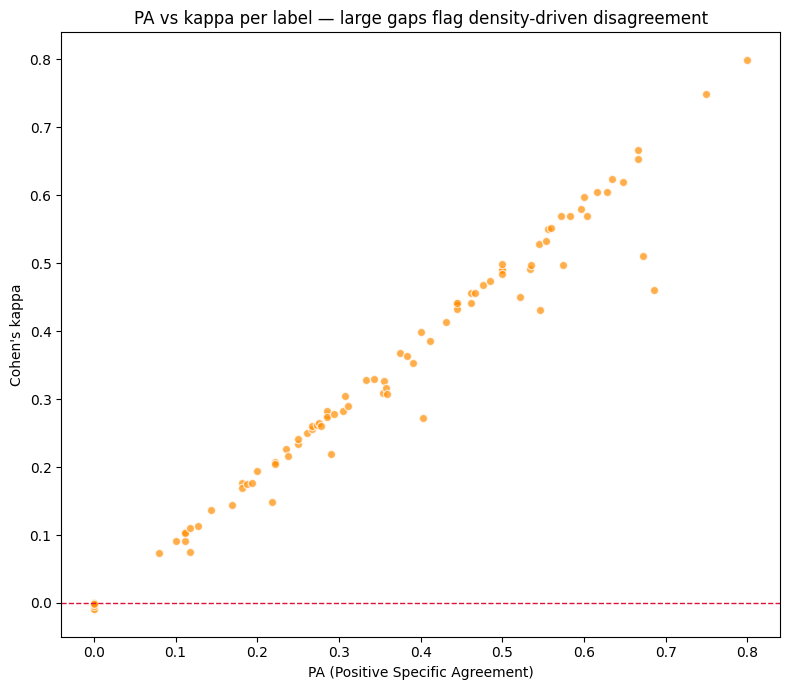

Spearman correlation between PA and kappa across labels: SignificanceResult(statistic=nan, pvalue=nan)


In [15]:
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(merged_all['PA'], merged_all['kappa'], s=35, alpha=0.7, edgecolor='white', color='darkorange')
ax.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax.set_xlabel('PA (Positive Specific Agreement)')
ax.set_ylabel("Cohen's kappa")
ax.set_title('PA vs kappa per label — large gaps flag density-driven disagreement')
plt.tight_layout()
plt.show()

print("Spearman correlation between PA and kappa across labels:",
      spearmanr(merged_all['PA'], merged_all['kappa']))

## Summary

Key numbers to report:

- Molecule-level `Score_m`: median / mean over all shared molecules, and its trend vs. `k`
- Label-level `PA`, `alpha`, `kappa`: how many labels fall below common reliability thresholds
- `Density`: whether disagreement correlates with annotation-density mismatches between datasets
- Prevalence correlation matrix: whether any dataset pair is a systematic outlier

All per-label and per-molecule results are saved as CSVs in `/mnt/user-data/outputs/` for
further analysis or inclusion in the paper.

In [16]:
print("=== SUMMARY ===")
print(f"Shared molecules (k>=2): {len(shared_smiles)}, with defined Score_m: {len(score_df)}")
print(f"Score_m — median: {score_df['Score_m'].median():.3f}, mean: {score_df['Score_m'].mean():.3f}")
print()
print(f"PA — median: {pa_df['PA'].median():.3f}, # labels PA<0.3: {(pa_df['PA']<0.3).sum()}/{len(pa_df)}")
print(f"alpha — median: {merged_pa_alpha['alpha'].median():.3f}, # labels alpha<0.2: {(merged_pa_alpha['alpha']<0.2).sum()}/{len(merged_pa_alpha)}")
print(f"kappa — median: {merged_all['kappa'].median():.3f}, # labels kappa<0.2: {(merged_all['kappa']<0.2).sum()}/{len(merged_all)}")
print()
print("Dataset label density (labels/molecule):")
print(density)

=== SUMMARY ===
Shared molecules (k>=2): 726, with defined Score_m: 724
Score_m — median: 0.273, mean: 0.314

PA — median: 0.250, # labels PA<0.3: 77/138
alpha — median: 0.230, # labels alpha<0.2: 60/138
kappa — median: 0.230, # labels kappa<0.2: 60/138

Dataset label density (labels/molecule):
goodscents     3.241133
leffingwell    3.606869
Name: Density, dtype: float64
